In [2]:
from google.colab import files

uploaded = files.upload()

Saving age_insurance.csv to age_insurance (1).csv


First 5 rows:
   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset shape:
(300, 3)

PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------

Accuracy:
0.7833333333333333

Classification Report:
               precision    recall  f1-score   support

 No Insurance       0.77      0.68      0.72        25
Has Insurance       0.79      0.86      0.82        35

     accuracy                           0.78        60
    macro avg       0.78      0.77      0.77        60
 weighted avg       0.78      0.78      0.78        60


Confusion Matrix:
[[17  8]
 [ 5 30]]

Predictions:
[0 1 1]

Predictions for new people:
Age 22: Insurance = 0 (probability of Yes = 0.07)
Age 45: Insurance = 1 (probability of Yes = 0.68)
Age 63: Insurance = 1 (probability of Yes = 0.97)


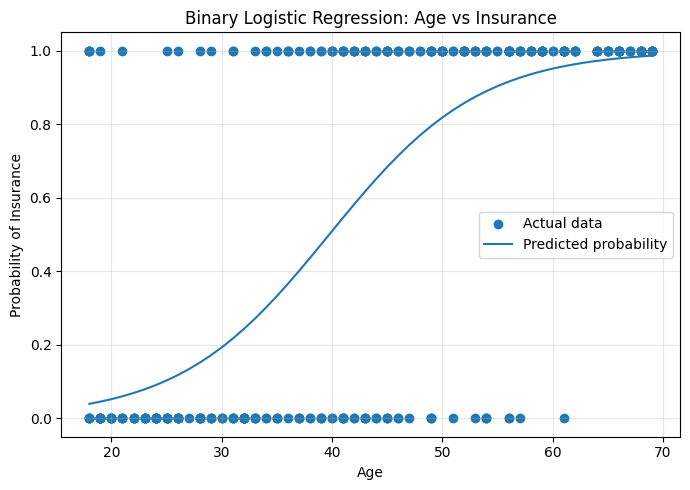


Saved plot -> binary_logistic_plot.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================================================
# STEP 1: Load the data
# =========================================================

df = pd.read_csv("age_insurance.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)


# =========================================================
# PART 1: BINARY LOGISTIC REGRESSION
# Feature: Age
# Target: Insurance
# 0 = No Insurance
# 1 = Has Insurance
# =========================================================

print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)


# Feature
X = df[["Age"]]

# Target
y = df["Insurance"]


# =========================================================
# STEP 2: TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =========================================================
# STEP 3: CREATE AND TRAIN MODEL
# =========================================================

binary_model = LogisticRegression()

binary_model.fit(
    X_train,
    y_train
)


# =========================================================
# STEP 4: PREDICTION
# =========================================================

y_pred = binary_model.predict(X_test)


# =========================================================
# STEP 5: MODEL EVALUATION
# =========================================================

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))


print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Insurance",
            "Has Insurance"
        ]
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


# =========================================================
# STEP 6: PREDICT FOR NEW AGES
# =========================================================

new_age = pd.DataFrame({
    "Age": [22, 45, 63]
})

predictions = binary_model.predict(new_age)

print("\nPredictions:")
print(predictions)


# Probability of Yes / Insurance
probabilities = binary_model.predict_proba(
    new_age
)[:, 1]


print("\nPredictions for new people:")

for age_val, pred, prob in zip(
    new_age["Age"],
    predictions,
    probabilities
):

    print(
        f"Age {age_val}: "
        f"Insurance = {pred} "
        f"(probability of Yes = {prob:.2f})"
    )


# =========================================================
# STEP 7: LOGISTIC REGRESSION S-CURVE
# =========================================================

plt.figure(figsize=(7, 5))


# Actual data
plt.scatter(
    df["Age"],
    df["Insurance"],
    label="Actual data"
)


# Age range
age_range = pd.DataFrame({
    "Age": range(
        int(df["Age"].min()),
        int(df["Age"].max()) + 1
    )
})


# Predicted probability
probability_curve = binary_model.predict_proba(
    age_range
)[:, 1]


# S-curve
plt.plot(
    age_range["Age"],
    probability_curve,
    label="Predicted probability"
)


plt.xlabel("Age")
plt.ylabel("Probability of Insurance")
plt.title(
    "Binary Logistic Regression: Age vs Insurance"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "binary_logistic_plot.png",
    dpi=150
)

plt.show()

print(
    "\nSaved plot -> binary_logistic_plot.png"
)